# Analysis of our Transformer model

In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score
from tqdm import tqdm
from pathlib import Path
from argparse import Namespace

module_path = Path("src").resolve()
sys.path.append(str(module_path))
from load_data import ProteinDataset, collate_fn, analyze_dataset
from new_file import custom_classifier
import classifier

## Set Parameters

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MAX_LEN = 128
BATCH_SIZE = 32

# Classes in dataset
label_cols = ['NO_S', 'LIP', 'S', 'TATLIP', 'PILI', 'TA']

args = {
    "max_len": MAX_LEN,
    "vocab_size": 23,
    "num_classes": len(label_cols),
    "num_heads": 16,
    "num_layers": 8,
    "embed_dim": 256,
    "attention_fn": "dot_prod",
    "Classifier": classifier.LinearClassifier,
    "classifier_reduction": "mean"
}
args = Namespace(**args)

## Load Dataset

In [4]:
# Load test dataframe
df = pd.read_csv("data/dataset_clean.csv")
analyze_dataset(df, label_cols=label_cols, sequence_col='sequence')

===== DATASET SUMMARY =====
Total rows: 25693
Total columns: 10

===== SEQUENCE LENGTH STATISTICS =====
Min length:   29
Max length:   69
Mean length:  68.90
Median length:69.00

===== LABEL DISTRIBUTION =====
NO_S                     : 19036
S                        : 3652
LIP                      : 2261
TA                       : 595
PILI                     : 113
TATLIP                   : 36

===== DONE =====


## Create Test dataset

In [4]:
# Create test data set, with same random state as during training
_, test_df = train_test_split(df, test_size=0.1, random_state=42, shuffle=True)
analyze_dataset(test_df, label_cols=label_cols, sequence_col='sequence')

# Dataset and DataLoader
test_dataset = ProteinDataset(test_df, label_cols, seq_col="sequence", max_len=MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

===== DATASET SUMMARY =====
Total rows: 2570
Total columns: 10

===== SEQUENCE LENGTH STATISTICS =====
Min length:   29
Max length:   69
Mean length:  68.91
Median length:69.00

===== LABEL DISTRIBUTION =====
NO_S                     : 1921
S                        : 359
LIP                      : 215
TA                       : 62
PILI                     : 7
TATLIP                   : 6

===== DONE =====


## Load Model

In [5]:
# Recreate model
model = custom_classifier(args)
model.load_state_dict(torch.load("model/signalP_dot_prod_mean_best_model.pt", map_location=DEVICE))
model.to(DEVICE)
model.eval()

custom_classifier(
  (transformer): SmallTransformer(
    (embed): Embedding(23, 256)
    (blocks): ModuleList(
      (0-7): 8 x TransformerEncoderBlock(
        (self_attn): MultiHeadedAttention(
          (Wq): Linear(in_features=256, out_features=256, bias=True)
          (Wk): Linear(in_features=256, out_features=256, bias=True)
          (Wv): Linear(in_features=256, out_features=256, bias=True)
          (Wo): Linear(in_features=256, out_features=256, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
        )
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): LinearClassifier(
    (classifier): Linear(i

## Run Model

In [6]:
all_preds = []
all_labels = []
all_emb = []

# Wrap the DataLoader with tqdm
test_loop = tqdm(test_loader, desc="Testing", leave=True)

# Run Model
with torch.no_grad():
    for batch in test_loop:
        sequences, labels, attention_mask = [b.to(DEVICE) for b in batch]
        logits, emb = model(sequences, attention_mask)
        all_preds.append(torch.sigmoid(logits).cpu())
        all_labels.append(labels.cpu())
        all_emb.append(emb.cpu())

        # Show running number of batches
        test_loop.set_postfix({"batch": f"{len(all_labels)}/{len(test_loader)}"})

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_emb = torch.cat(all_emb)

Testing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [01:46<00:00,  1.31s/it, batch=81/81]


### Save results

In [7]:
torch.save({
    "labels": all_labels,
    "predictions": all_preds,
    "embeddings": all_emb
}, "data/results/dot_prod_results.pt")

### Load saved results

In [5]:
data = torch.load("data/results/dot_prod_results.pt")
all_labels = data["labels"]
all_preds = data["predictions"]
all_emb = data["embeddings"]

### Evaluate results

In [82]:
# Binary predictions (threshold 0.5)
preds_bin = (all_preds >= 0.5).float()

# Macro F1
macro_f1 = f1_score(all_labels, preds_bin, average="macro", zero_division=0)
print("Test Macro F1:", macro_f1)

# Per-class F1 / ROC-AUC
for i, label in enumerate(label_cols):
    f1 = f1_score(all_labels[:, i], preds_bin[:, i], zero_division=0)
    try:
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
    except ValueError:
        auc = float('nan')
    print(f"{label:20s} - F1: {f1:.4f} - ROC-AUC: {auc:.4f}")

Test Macro F1: 0.7860987961698487
NO_S                 - F1: 0.9757 - ROC-AUC: 0.9814
LIP                  - F1: 0.8838 - ROC-AUC: 0.9897
S                    - F1: 0.8455 - ROC-AUC: 0.9709


TATLIP               - F1: 0.4615 - ROC-AUC: 0.9502
PILI                 - F1: 0.7500 - ROC-AUC: 0.9692
TA                   - F1: 0.8000 - ROC-AUC: 0.9694


In [7]:
print("Model summary:")
print(f"Labels are of shape:\t\t{all_labels.shape}")
print(f"Predictions are of shape:\t{all_preds.shape}")
print(f"Embeddings are of shape:\t{all_emb.shape}")

Model summary:
Labels are of shape:		torch.Size([2570, 6])
Predictions are of shape:	torch.Size([2570, 6])
Embeddings are of shape:	torch.Size([2570, 256])


## Plot results

tensor([12850,  2570])
CLass accuracy:  [0.98006296 0.87330317 0.83783784 0.42857143 0.75       0.82758621]


<BarContainer object of 6 artists>

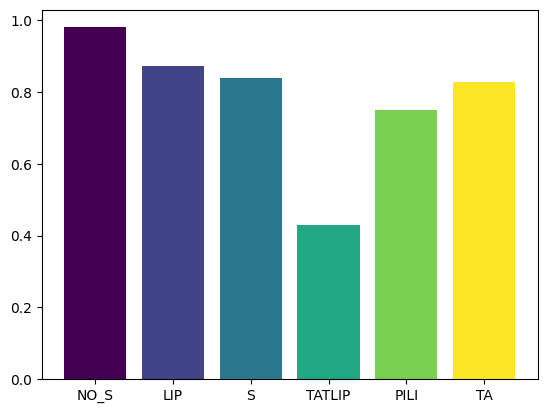

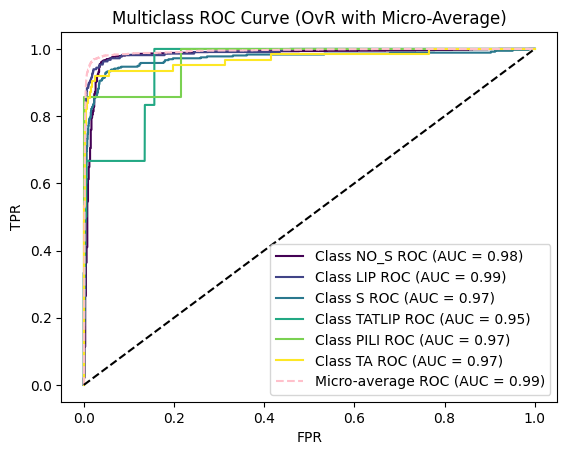

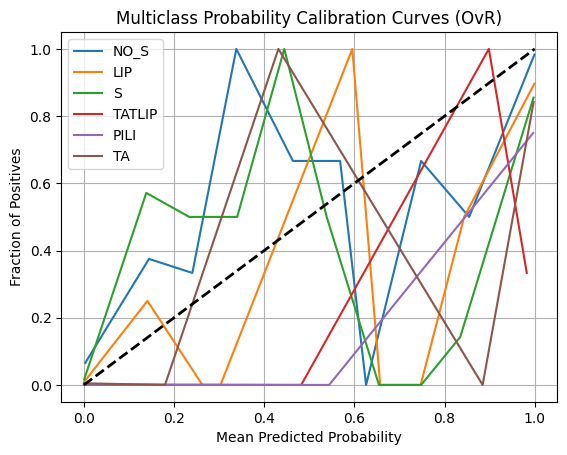

Optimal T: 0.2169185469964157


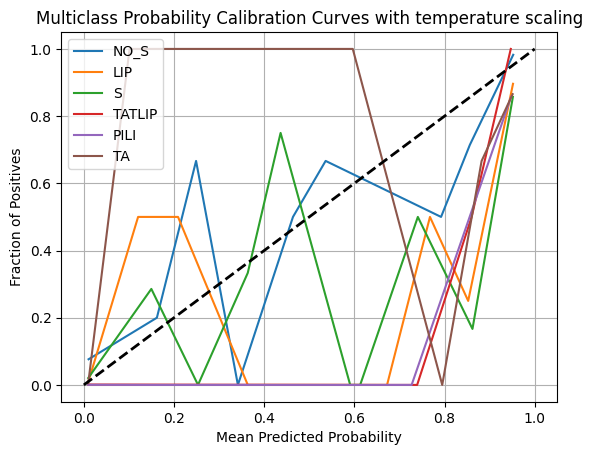

In [ ]:
from sklearn.calibration import calibration_curve


ECE: 0.0159
MCE: 0.7036
Brier score: 0.1023
Log-loss: 0.2790


Variance explained:  [6.14194531e-01 2.48474302e-01 6.77293786e-02 9.63456059e-03
 8.34869867e-03 7.50674360e-03 4.19989478e-03 3.80315692e-03
 2.94197201e-03 2.74197806e-03 2.09742405e-03 1.80106516e-03
 1.61045792e-03 1.54316660e-03 1.44613650e-03 1.35211574e-03
 1.22061977e-03 1.07821418e-03 1.05493273e-03 9.81799167e-04
 8.77189883e-04 8.47803896e-04 7.13016849e-04 6.59664415e-04
 6.12740518e-04 5.84282183e-04 5.18219844e-04 4.76187567e-04
 4.63497280e-04 4.58173988e-04 3.76670555e-04 3.73355435e-04
 3.51308518e-04 3.26481802e-04 3.20229487e-04 2.85571333e-04
 2.63326348e-04 2.60321707e-04 2.41770381e-04 2.22058703e-04
 2.18306976e-04 2.06558340e-04 1.90416671e-04 1.79503851e-04
 1.72394303e-04 1.70771855e-04 1.65597684e-04 1.58058395e-04
 1.51040516e-04 1.44220760e-04 1.35935752e-04 1.31311815e-04
 1.25343020e-04 1.21900106e-04 1.16292028e-04 1.13831161e-04
 1.11927400e-04 1.06268178e-04 1.00343695e-04 9.65021720e-05
 9.52973100e-05 9.32412642e-05 8.98400660e-05 8.55777082e-05
 8.

/tmp/ipykernel_18558/2189662367.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


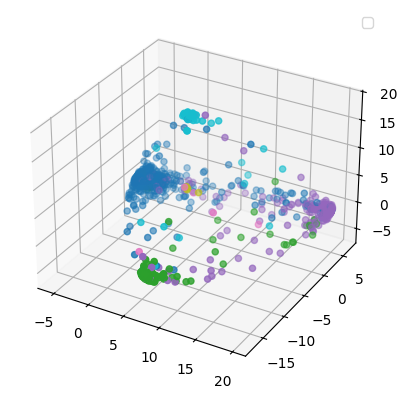

In [ ]:

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(embeds_pca[:,0], embeds_pca[:,1], embeds_pca[:,2], c = labels_int, cmap = "tab10" )
plt.legend()
plt.show()


/tmp/ipykernel_18558/466631361.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  all_emb_norm = all_emb / np.linalg.norm(all_emb, axis = 1, keepdims= True)
/tmp/ipykernel_18558/466631361.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


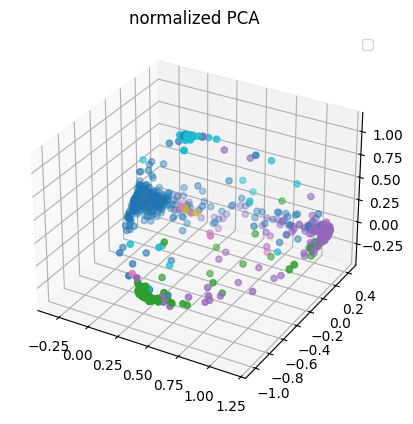

In [ ]:

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(all_emb_norm_pca[:,0], all_emb_norm_pca[:,1], all_emb_norm_pca[:,2], c = labels_int, cmap = "tab10" )
ax.set_title("normalized PCA")
plt.legend()
plt.show()


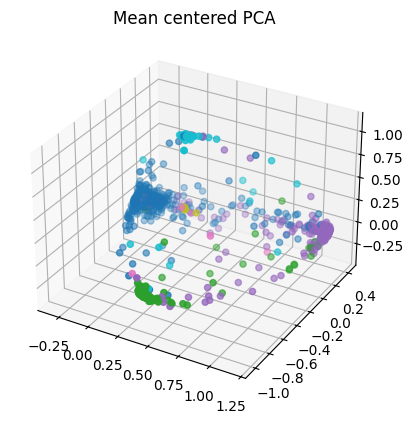

In [ ]:
from sklearn.metrics import roc_curve,auc
from sklearn.calibration import calibration_curve
from scipy.optimize import minimize
from sklearn.metrics import brier_score_loss, log_loss
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


def evaluation_plots(data, kernel):
    all_labels = data["labels"]
    all_preds = data["predictions"]
    all_emb = data["embeddings"]
    values, counts = torch.unique(all_labels, return_counts=True)
    print(counts)
    true_predicted = [0,0,0,0,0,0]
    false_predicted = [0,0,0,0,0,0]

    for pred, lab in zip(all_preds, all_labels):
        p = np.argmax(pred)
        l = np.argmax(lab)
        if p == l:
            true_predicted[p] += 1
        else:
            false_predicted[p] += 1

    print("CLass accuracy: ", np.array(true_predicted) / (np.array(false_predicted) + np.array(true_predicted)))
    colors = plt.cm.viridis(np.linspace(0, 1, 6))
    plt.bar(x = label_cols, height = np.array(true_predicted) / (np.array(false_predicted) + np.array(true_predicted)), color = colors)
    plt.title(kernel + " Class accuracies")

    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(6):
        fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_preds[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels.ravel(), all_preds.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    for i,lab in enumerate(label_cols):
        plt.plot(
            fpr[i], tpr[i],
            label=f"Class {lab} ROC (AUC = {roc_auc[i]:.2f})",
            color = colors[i]
        )

    plt.plot(
        fpr["micro"], tpr["micro"],
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.2f})",
        linestyle="--",
        color ="pink"
    )

    plt.plot([0, 1], [0, 1], "k--")

    plt.title(kernel + " Multiclass ROC Curve (OvR with Micro-Average)")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend(loc="lower right")
    plt.show()

    for i in range(6):
        prob_true, prob_pred = calibration_curve(
            all_labels[:, i], all_preds[:, i], n_bins=10
        )
        width = 0.007
        offset = (i - 6/2) * width * 1.5
        #offset = 0
        #plt.bar(prob_pred + offset, prob_true, width=width, alpha=0.7, label=f"Class {i}")
        plt.plot(prob_pred, prob_true, label=label_cols[i])

    plt.plot([0, 1], [0, 1], "k--", linewidth=2)
        #plt.show()
    plt.title(kernel + " Multiclass Probability Calibration Curves (OvR)")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

    # find optimal temperature
    def softmax(z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def nll(logits, labels, T):
        scaled = logits / T
        probs = softmax(scaled)
        return -np.mean(np.log(probs[np.arange(len(labels)), labels]))

    def find_temperature(logits, labels):
        def objective(logT):
            T = np.exp(logT)
            return nll(logits, labels, T)
        res = minimize(objective, x0=[0.0], method='L-BFGS-B')
        return float(np.exp(res.x[0]))

    logits = all_preds.detach().cpu().numpy()
    labels = all_labels.detach().cpu().numpy().astype(int)
    labels_int = labels.argmax(axis=1)  
    T = find_temperature(logits, labels_int)
    print("Optimal T:", T)

    temp_preds = softmax(logits / T)
    for i in range(6):
        prob_true, prob_pred = calibration_curve(
            all_labels[:, i], temp_preds[:, i], n_bins=10
        )
        width = 0.007
        offset = (i - 6/2) * width * 1.5
        #offset = 0
        #plt.bar(prob_pred + offset, prob_true, width=width, alpha=0.7, label=f"Class {i}")
        plt.plot(prob_pred, prob_true, label=label_cols[i])

        plt.plot([0, 1], [0, 1], "k--", linewidth=2)
        #plt.show()
    plt.title(kernel + " Multiclass Probability Calibration Curves with temperature scaling")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.legend()
    plt.grid(True)
    plt.show()

    def expected_calibration_error(probs, labels, n_bins=15):
        """ECE: weighted average of |accuracy - confidence| across bins"""
        bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
        ece = 0.0
        mce = 0.0
        confidences = probs.max(axis=1)
        predictions = probs.argmax(axis=1)
        
        for i in range(n_bins):
            low, high = bin_edges[i], bin_edges[i+1]
            mask = (confidences > low) & (confidences <= high) if i>0 else (confidences >= low) & (confidences <= high)
            if np.sum(mask) == 0:
                continue
            acc = np.mean(predictions[mask] == labels[mask])
            conf = np.mean(confidences[mask])
            ece += np.sum(mask) / len(labels) * abs(acc - conf)
            mce = max(mce, abs(acc - conf))
        return ece, mce

    ece, mce = expected_calibration_error(temp_preds, labels_int)
    brier = brier_score_loss(np.eye(6)[labels_int], temp_preds)
    logloss = log_loss(labels_int, temp_preds)

    print(f"{kernel} ECE: {ece:.4f}") # Expected calibration error -> really good
    print(f"{kernel}  MCE: {mce:.4f}") # Mean calibration error -> some are really far off
    print(f"{kernel}  Brier score: {brier:.4f}") # brier score is okay
    print(f"{kernel}  Log-loss: {logloss:.4f}") # log loss is really good


    pca = PCA()
    print("Variance explained: ",pca.fit(all_emb).explained_variance_ratio_)

    all_emb_norm = all_emb / np.linalg.norm(all_emb, axis = 1, keepdims= True)
    all_emb_norm_mean_centered = all_emb_norm - all_emb_norm.mean(axis = 0, keepdims = True)
    all_emb_norm_mean_centered_pca = PCA().fit_transform(all_emb_norm_mean_centered)
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(all_emb_norm_mean_centered_pca[:,0], all_emb_norm_mean_centered_pca[:,1], all_emb_norm_mean_centered_pca[:,2], c = labels_int, cmap = "tab10" )
    ax.set_title(kernel + " Mean centered PCA")
    plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2576493528.py, line 38)